In [103]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dropout, Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.optimizers import Adam
import statistics

In [104]:
print('Inicio:',datetime.now())

Inicio: 2026-05-31 20:36:32.714890


In [105]:
# Lectura de datasets 
gripe=pd.read_csv("../Notebooks enfermedades/flu_esp_indexado.csv", sep=",",index_col=0) 
humedad=pd.read_csv("../Notebooks meteorologia/humedad_semanal_esp.csv", sep=",",index_col=0) 
temperatura=pd.read_csv("../Notebooks meteorologia/temperatura_semanal_esp.csv", sep=",",index_col=0) 
viento=pd.read_csv("../Notebooks meteorologia/viento_semanal_esp.csv", sep=",",index_col=0) 
precipitaciones=pd.read_csv("../Notebooks meteorologia/precipitaciones_semanales_esp.csv", sep=",",index_col=0) 
trends=pd.read_csv("../Notebooks google trends/flu_trends.csv", sep=",",index_col=0) 

In [106]:
# Unificación de datasets
gripe_tot=pd.concat([gripe,temperatura,humedad,viento,precipitaciones,trends],axis=1)
gripe_tot.index = pd.to_datetime(gripe_tot.index)
df=gripe_tot.dropna()

In [107]:
#Incluimos variables númericas para los meses y las semanas
df['mes']=df.index.month
df['semana']=df.index.isocalendar().week
df

,INF_ALL,TG,HU,FG,RR,gripe_trends,mes,semana
2013-09-29,1.0,216.192308,64.974790,27.482993,16.123810,43,9,39
2013-10-06,1.0,209.357143,69.941176,28.659864,14.800000,44,10,40
2013-10-13,0.0,175.554945,65.201681,26.503401,2.514286,70,10,41
2013-10-20,1.0,188.945055,66.605042,25.421769,11.504762,54,10,42
2013-10-27,0.0,183.302198,70.630252,29.639456,41.180952,50,10,43
...,...,...,...,...,...,...,...,...
2025-02-23,166.0,127.093407,73.260504,27.136054,7.180952,28,2,8
2025-03-02,76.0,107.329670,70.747899,31.666667,35.844444,22,3,9
2025-03-09,117.0,122.423077,79.672269,37.414966,71.388889,20,3,10
2025-03-16,65.0,101.659341,74.319328,29.843537,46.428571,19,3,11


In [108]:
df.corr(method='pearson')

,INF_ALL,TG,HU,FG,RR,gripe_trends,mes,semana
INF_ALL,1.000000,-0.498513,0.368581,-0.125674,0.100819,0.551141,-0.363697,-0.357238
TG,-0.498513,1.000000,-0.709955,0.175184,-0.360496,-0.515073,0.295400,0.260792
HU,0.368581,-0.709955,1.000000,-0.401470,0.589630,0.494141,0.081417,0.112517
FG,-0.125674,0.175184,-0.401470,1.000000,0.121672,-0.240522,-0.246429,-0.274921
RR,0.100819,-0.360496,0.589630,0.121672,1.000000,0.164511,0.056190,0.052971
gripe_trends,0.551141,-0.515073,0.494141,-0.240522,0.164511,1.000000,-0.016008,0.024217
mes,-0.363697,0.295400,0.081417,-0.246429,0.056190,-0.016008,1.000000,0.947200
semana,-0.357238,0.260792,0.112517,-0.274921,0.052971,0.024217,0.947200,1.000000


Función de normalización

In [109]:
def split_data(df,test_split=0.1):
    n=int(len(df)*test_split)
    train,test=df[:-n],df[-n:]
    return train, test

### Gradient boosting con todas las variables

In [110]:
train1,test1=split_data(df)

In [111]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
train_norm1=pd.DataFrame(norm.fit_transform(train1),index=train1.index,columns=train1.columns)
test_norm1=pd.DataFrame(norm.transform(test1),index=test1.index,columns=test1.columns)

In [112]:
xtrainN1=train_norm1.iloc[:,1:]
xtestN1=test_norm1.iloc[:,1:]
ytrainN1=train_norm1.iloc[:,0]
ytestN1=test_norm1.iloc[:,0]
xtrainN1.shape

(472, 7)

### Gradient boosting (learning rate=0.25)

In [113]:
gbr_lr=GradientBoostingRegressor(random_state=0,learning_rate=0.25) #learning rate 0.25
gbr_lr.fit(xtrainN1,ytrainN1)
ypred_gbr=gbr_lr.predict(xtestN1.values.astype(np.float32))
Y_gbr_lr=pd.DataFrame(ytestN1,index=ytestN1.index).rename({'INF_ALL':'ytest'},axis=1)
Y_gbr_lr['ypred']=pd.DataFrame(ypred_gbr,index=ytestN1.index)

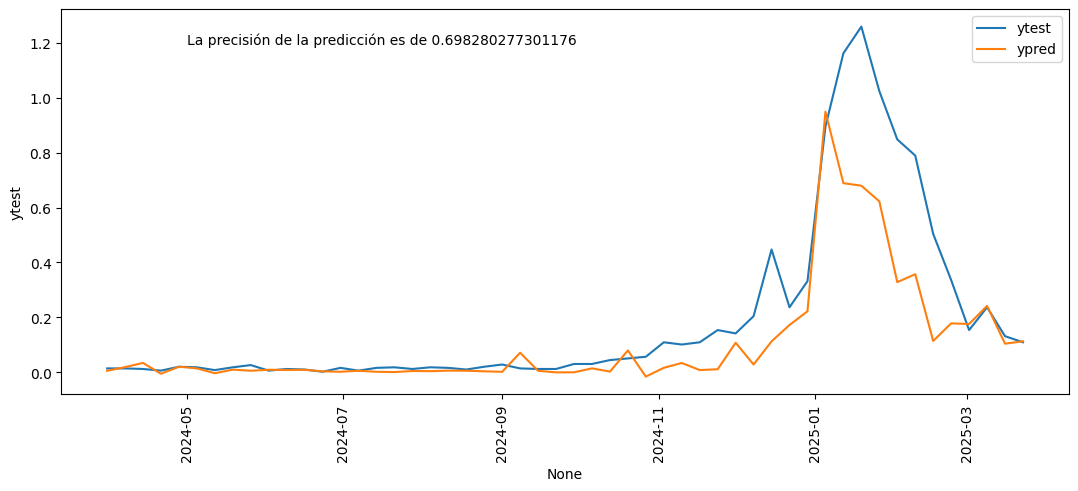

In [114]:
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_gbr_lr,x=Y_gbr_lr.index,y=Y_gbr_lr.ytest,label='ytest')
sns.lineplot(data=Y_gbr_lr,x=Y_gbr_lr.index,y=Y_gbr_lr.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2024, 5, 1), 0.95*max(Y_gbr_lr.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_gbr_lr.ytest, Y_gbr_lr.ypred)), fontsize=10)
plt.show()

### Cálculo de la ventana deslizante lag 4 todas 

In [115]:
def one_step_forecast(df, window):
    d = df.values
    x = []
    n = len(df)
    idx = df.index[:-window]
    for start in range(n-window):
        end = start + window
        x.append(d[start:end])
    cols = [f'x_{i}' for i in range(1, window+1)]
    x = np.array(x).reshape(n-window, -1)
    y = df.iloc[window:].values
    df_xs = pd.DataFrame(x, columns=cols, index=idx)
    df_y = pd.DataFrame(y.reshape(-1), columns=['y'], index=idx)
    return pd.concat([df_y,df_xs], axis=1).dropna()

In [116]:
df_inf=one_step_forecast(df.iloc[:,0],4) #ventana deslizante de infectados
df_temp=one_step_forecast(df.iloc[:,1],4).iloc[:,1:].rename({'x_1':'x_1_temp','x_2':'x_2_temp','x_3':'x_3_temp','x_4':'x_4_temp'},axis=1)
df_hum=one_step_forecast(df.iloc[:,2],4).iloc[:,1:].rename({'x_1':'x_1_hum','x_2':'x_2_hum','x_3':'x_3_hum','x_4':'x_4_hum'},axis=1)
df_wind=one_step_forecast(df.iloc[:,3],4).iloc[:,1:].rename({'x_1':'x_1_wind','x_2':'x_2_wind','x_3':'x_3_wind','x_4':'x_4_wind'},axis=1)
df_prep=one_step_forecast(df.iloc[:,4],4).iloc[:,1:].rename({'x_1':'x_1_prep','x_2':'x_2_prep','x_3':'x_3_prep','x_4':'x_4_prep'},axis=1)
df_trend=one_step_forecast(df.iloc[:,5],4).iloc[:,1:].rename({'x_1':'x_1_tre','x_2':'x_2_tre','x_3':'x_3_tre','x_4':'x_4_tre'},axis=1)
df_mes=one_step_forecast(df.iloc[:,6],4).iloc[:,1:].rename({'x_1':'x_1_mes','x_2':'x_2_mes','x_3':'x_3_mes','x_4':'x_4_mes'},axis=1)
df_sem=one_step_forecast(df.iloc[:,7],4).iloc[:,1:].rename({'x_1':'x_1_sem','x_2':'x_2_sem','x_3':'x_3_sem','x_4':'x_4_sem'},axis=1)

In [117]:
df2=pd.concat([df_inf.iloc[:,:2],df_temp.iloc[:,0],df_trend.iloc[:,0],df_mes.iloc[:,0],df_hum.iloc[:,0],df_wind.iloc[:,0],df_prep.iloc[:,0],df_sem.iloc[:,0],
              df_inf.iloc[:,2],df_temp.iloc[:,1],df_trend.iloc[:,1],df_mes.iloc[:,1],df_hum.iloc[:,1],df_wind.iloc[:,1],df_prep.iloc[:,1],df_sem.iloc[:,1],
              df_inf.iloc[:,3],df_temp.iloc[:,2],df_trend.iloc[:,2],df_mes.iloc[:,2],df_hum.iloc[:,2],df_wind.iloc[:,2],df_prep.iloc[:,2],df_sem.iloc[:,2],
              df_inf.iloc[:,4],df_temp.iloc[:,3],df_trend.iloc[:,3],df_mes.iloc[:,3],df_hum.iloc[:,3],df_wind.iloc[:,3],df_prep.iloc[:,3],df_sem.iloc[:,3]
              ],axis=1)
df2

,y,x_1,x_1_temp,x_1_tre,x_1_mes,x_1_hum,x_1_wind,x_1_prep,x_1_sem,x_2,...,x_3_prep,x_3_sem,x_4,x_4_temp,x_4_tre,x_4_mes,x_4_hum,x_4_wind,x_4_prep,x_4_sem
2013-09-29,0.0,1.0,216.192308,43,9,64.974790,27.482993,16.123810,39,1.0,...,2.514286,41,1.0,188.945055,54,10,66.605042,25.421769,11.504762,42
2013-10-06,1.0,1.0,209.357143,44,10,69.941176,28.659864,14.800000,40,0.0,...,11.504762,42,0.0,183.302198,50,10,70.630252,29.639456,41.180952,43
2013-10-13,0.0,0.0,175.554945,70,10,65.201681,26.503401,2.514286,41,1.0,...,41.180952,43,1.0,147.148352,47,11,62.268908,31.081633,10.352381,44
2013-10-20,3.0,1.0,188.945055,54,10,66.605042,25.421769,11.504762,42,0.0,...,10.352381,44,0.0,158.576923,45,11,67.865546,41.748299,10.133333,45
2013-10-27,6.0,0.0,183.302198,50,10,70.630252,29.639456,41.180952,43,1.0,...,10.133333,45,3.0,123.417582,44,11,68.285714,32.428571,41.057143,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-26,166.0,506.0,116.620879,58,1,76.075630,31.578231,27.590476,4,419.0,...,8.466667,6,249.0,118.736264,34,2,72.739496,25.176871,10.428571,7
2025-02-02,76.0,419.0,98.769231,45,2,69.294118,39.945578,25.247619,5,390.0,...,10.428571,7,166.0,127.093407,28,2,73.260504,27.136054,7.180952,8
2025-02-09,117.0,390.0,90.467033,41,2,71.915966,25.945578,8.466667,6,249.0,...,7.180952,8,76.0,107.329670,22,3,70.747899,31.666667,35.844444,9
2025-02-16,65.0,249.0,118.736264,34,2,72.739496,25.176871,10.428571,7,166.0,...,35.844444,9,117.0,122.423077,20,3,79.672269,37.414966,71.388889,10


### Normalización y separación en test y train

In [118]:
train2,test2=split_data(df2)

In [119]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
train_norm2=pd.DataFrame(norm.fit_transform(train2),index=train2.index,columns=train2.columns)
test_norm2=pd.DataFrame(norm.transform(test2),index=test2.index,columns=test2.columns)

In [120]:
xtrainN2=train_norm2.iloc[:,1:]
xtestN2=test_norm2.iloc[:,1:]
ytrainN2=train_norm2.iloc[:,0]
ytestN2=test_norm2.iloc[:,0]
xtrainN2.shape

(468, 32)

### Regresión lineal

In [121]:
from sklearn import linear_model
regr=linear_model.LinearRegression()
regr.fit(xtrainN2,ytrainN2)
ypred=regr.predict(xtestN2)
Y_rl=pd.DataFrame(ytestN2,index=ytestN2.index).rename({'y':'ytest'},axis=1)
Y_rl['ypred']=pd.DataFrame(ypred,index=ytestN2.index)
#Y_rl

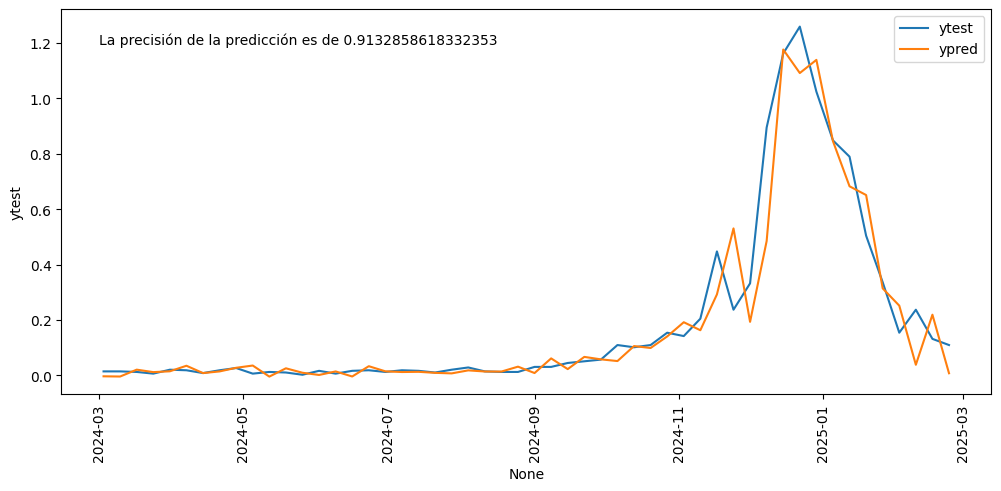

In [122]:
plt.figure(figsize=(12,5))
sns.lineplot(data=Y_rl,x=Y_rl.index,y=Y_rl.ytest,label='ytest')
sns.lineplot(data=Y_rl,x=Y_rl.index,y=Y_rl.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2024, 3, 1), 0.95*max(Y_rl.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_rl.ytest, Y_rl.ypred)), fontsize=10)
plt.show()

### lag 4 variables seleccionadas

In [123]:
df3=pd.concat([df_inf.iloc[:,:2],df_temp.iloc[:,0],df_trend.iloc[:,0],df_mes.iloc[:,0],df_inf.iloc[:,2],
              df_temp.iloc[:,1],df_trend.iloc[:,1],df_mes.iloc[:,1],df_inf.iloc[:,3],df_temp.iloc[:,2],
              df_trend.iloc[:,2],df_mes.iloc[:,2],df_inf.iloc[:,4],df_temp.iloc[:,3],df_trend.iloc[:,3],
              df_mes.iloc[:,3]],axis=1)
df3

,y,x_1,x_1_temp,x_1_tre,x_1_mes,x_2,x_2_temp,x_2_tre,x_2_mes,x_3,x_3_temp,x_3_tre,x_3_mes,x_4,x_4_temp,x_4_tre,x_4_mes
2013-09-29,0.0,1.0,216.192308,43,9,1.0,209.357143,44,10,0.0,175.554945,70,10,1.0,188.945055,54,10
2013-10-06,1.0,1.0,209.357143,44,10,0.0,175.554945,70,10,1.0,188.945055,54,10,0.0,183.302198,50,10
2013-10-13,0.0,0.0,175.554945,70,10,1.0,188.945055,54,10,0.0,183.302198,50,10,1.0,147.148352,47,11
2013-10-20,3.0,1.0,188.945055,54,10,0.0,183.302198,50,10,1.0,147.148352,47,11,0.0,158.576923,45,11
2013-10-27,6.0,0.0,183.302198,50,10,1.0,147.148352,47,11,0.0,158.576923,45,11,3.0,123.417582,44,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-26,166.0,506.0,116.620879,58,1,419.0,98.769231,45,2,390.0,90.467033,41,2,249.0,118.736264,34,2
2025-02-02,76.0,419.0,98.769231,45,2,390.0,90.467033,41,2,249.0,118.736264,34,2,166.0,127.093407,28,2
2025-02-09,117.0,390.0,90.467033,41,2,249.0,118.736264,34,2,166.0,127.093407,28,2,76.0,107.329670,22,3
2025-02-16,65.0,249.0,118.736264,34,2,166.0,127.093407,28,2,76.0,107.329670,22,3,117.0,122.423077,20,3


In [124]:
train3,test3=split_data(df3)

In [125]:
from sklearn.preprocessing import MinMaxScaler
norm3=MinMaxScaler()
train_norm3=pd.DataFrame(norm3.fit_transform(train3),index=train3.index,columns=train3.columns)
test_norm3=pd.DataFrame(norm3.transform(test3),index=test3.index,columns=test3.columns)

In [126]:
xtrainN3=train_norm3.iloc[:,1:]
xtestN3=test_norm3.iloc[:,1:]
ytrainN3=train_norm3.iloc[:,0]
ytestN3=test_norm3.iloc[:,0]
xtrainN3.shape

(468, 16)

In [127]:
xtrainN3,xvalN3=split_data(xtrainN3)
ytrainN3,yvalN3=split_data(ytrainN3)

In [128]:
Y_rna11=pd.DataFrame(ytestN3,index=ytestN3.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    rna11=Sequential()
    rna11.add(Dense(units=64,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN3.columns))))
    rna11.add(Dropout(0.1))
    rna11.add(Dense(units=64,kernel_initializer='uniform',activation='relu'))
    rna11.add(Dropout(0.1))
    rna11.add(Dense(1))
    rna11.compile(optimizer=Adam(learning_rate=0.003),loss='mean_squared_error')
    rna11.fit(xtrainN3,ytrainN3,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN3,yvalN3))
    ypred_rna11=rna11.predict(xtestN3)
    Y_rna11['ypred_'+str(i)]=pd.DataFrame(ypred_rna11,index=ytestN3.index)

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0477 - val_loss: 0.0254
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0234 - val_loss: 0.0227
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0156 - val_loss: 0.0213
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0116 - val_loss: 0.0108
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0083 - val_loss: 0.0097
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0074 - val_loss: 0.0101
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0063 - val_loss: 0.0072
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0060 - val_loss: 0.0073
Epoch 9/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0062 - val_loss: 0.0076
Epoch 10/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0049 - val_loss: 0.0055
Epoch 11/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0046 - val_loss: 0.0075
Epoch 12/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0054 - val_lo

In [129]:
Y_rna11['ypred_T']=0
for i in range(0,Y_rna11.shape[0]):
    Y_rna11['ypred_T'][i]=(Y_rna11['ypred_0'][i]+Y_rna11['ypred_1'][i]+Y_rna11['ypred_2'][i]+Y_rna11['ypred_3'][i])/4

Y_rna11

,ytest,ypred_0,ypred_1,ypred_2,ypred_3,ypred_T
2024-03-03,0.014170,0.017254,0.046539,0.016262,0.014789,0.023711
2024-03-10,0.014170,0.023927,0.030737,0.026868,0.023178,0.026177
2024-03-17,0.012146,0.003485,-0.002189,0.008719,0.013026,0.005760
2024-03-24,0.006073,0.005261,0.010861,0.007456,0.002597,0.006544
2024-03-31,0.020243,0.004518,0.004975,0.006334,0.006296,0.005531
2024-04-07,0.018219,0.004234,-0.002555,0.009412,0.005702,0.004198
2024-04-14,0.008097,0.002596,-0.004293,0.007607,0.003553,0.002366
2024-04-21,0.018219,0.003656,-0.000748,0.006209,0.001402,0.002630
2024-04-28,0.026316,0.014693,0.007960,0.009339,0.003861,0.008963
2024-05-05,0.006073,0.003545,-0.002610,0.007050,0.004369,0.003089


In [130]:
v3=r2_score(Y_rna11.iloc[:,0], Y_rna11.iloc[:,5])
a3=mean_squared_error(Y_rna11.iloc[:,0], Y_rna11.iloc[:,5])
k3=mean_absolute_error(Y_rna11.iloc[:,0], Y_rna11.iloc[:,5])

print(v3)
print(k3)
print(a3)

0.948707002391719
0.043176974814925516
0.0051625780182884655


In [131]:
Y_rl=Y_rl.set_index(Y_gbr_lr.index)

In [132]:
Y_rna11=Y_rna11.set_index(Y_gbr_lr.index)

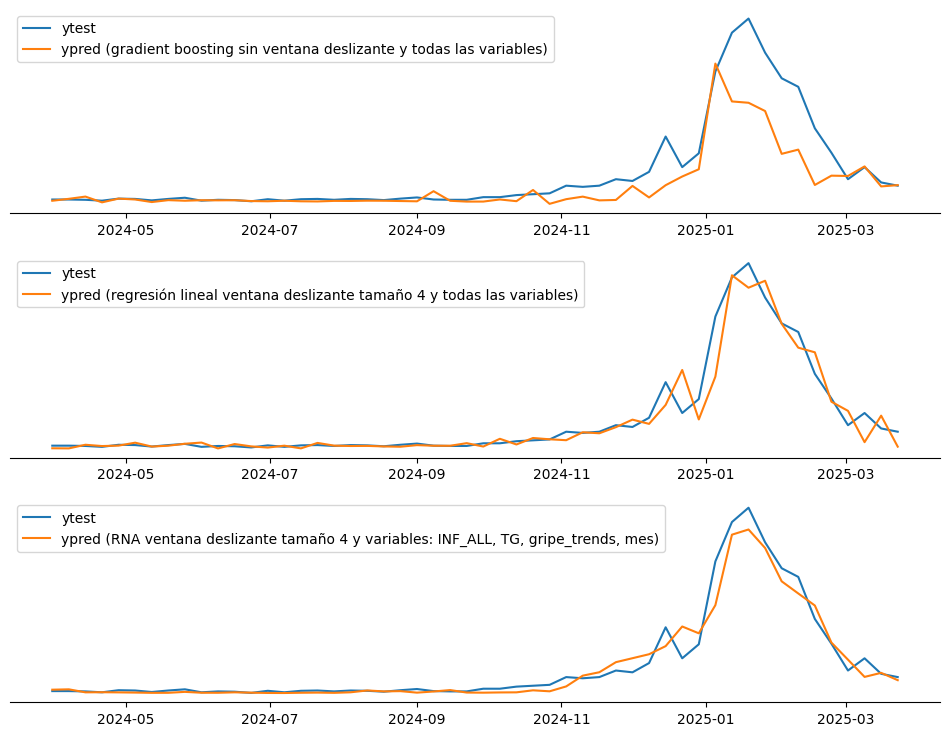

In [133]:
fig,ax=plt.subplots(3,1,figsize=(12,9))
sns.lineplot(data=Y_gbr_lr,x=Y_gbr_lr.index,y=Y_gbr_lr.ytest,label='ytest',ax=ax[0])
sns.lineplot(data=Y_gbr_lr,x=Y_gbr_lr.index,y=Y_gbr_lr.ypred,label='ypred (gradient boosting sin ventana deslizante y todas las variables)',ax=ax[0])
sns.lineplot(data=Y_gbr_lr,x=Y_gbr_lr.index,y=Y_gbr_lr.ytest,label='ytest',ax=ax[1])
sns.lineplot(data=Y_rl,x=Y_rl.index,y=Y_rl.ypred,label='ypred (regresión lineal ventana deslizante tamaño 4 y todas las variables)',ax=ax[1])
sns.lineplot(data=Y_gbr_lr,x=Y_gbr_lr.index,y=Y_gbr_lr.ytest,label='ytest',ax=ax[2])
sns.lineplot(data=Y_rna11,x=Y_rna11.index,y=Y_rna11.ypred_T,label='ypred (RNA ventana deslizante tamaño 4 y variables: INF_ALL, TG, gripe_trends, mes)',ax=ax[2])

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[0].yaxis.set_ticks([])
ax[0].set(ylabel=None)
ax[0].set_xlabel("")

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['left'].set_visible(False)
ax[1].yaxis.set_ticks([])
ax[1].set(ylabel=None)
ax[1].set_xlabel("")

ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)
ax[2].spines['left'].set_visible(False)
ax[2].yaxis.set_ticks([])
ax[2].set(ylabel=None)
ax[2].set_xlabel("")

plt.legend()
#plt.xticks(rotation=90)
plt.show()